## Heathcare Resource Allocation

The trust of a hospital in mental health services struggles with operational issues caused by unpredictable walk-in patients and scheduled appointments, leading to bottlenecks and long waiting times. As a result, waiting times have increased and inefficiencies significantly impact outpatient services. The hospital is now interested in exploring how mathematical modeling can optimize resource allocation to improve service delivery.

Here, we will prepare a mathematical model using the M/M/c queuing model to simulate the queue in the clinic to understand how the varying arrival rates of patients affect the operational efficiency of the clinic.

The notebook is divided into two sections. The first section presents a model that simulates the issue and explores how fluctuating arrival rates impact the queue. The second section introduces a model that incorporates allocation strategies, examining how the implementation of `splitting` and `dynamic allocation` strategies can enhance service and reduce patient wait times in the queue.

First, install the `SimPy library`.
SimPy is a process-based discrete-event simulation framework which helps to simulate a situation. 
We will use this to run a simulation to understand the arrival and the waiting timing of the paitients in the queue.

In [1]:
pip install simpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\kumar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Section 1: Modelling the situtation

Import all the necessary libraries

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Queue Simulation

To simulate a queue model, we will be using `M/M/c` queue model with c (number of clinicians) = 4.
Following are the input parameters: 
`lambda_rate` (rate of arrival, $\lambda$), `mu_rate` (rate of service, $\mu$) and `duration` (in minutes). 

The systme is modelled as `Markovian` (Memoryless), here the future of the system is independent of the past and only depends on the current stage.

## Arrival process:
We assume that new customers arrive according to a Markovian process, with an average arrival rate of $\lambda$. In this case, we can model the arrivals using a Poisson process, which counts the number of events occurring within a given time period, $t$, given by:
$$
    \begin{align*}
		&N(0) = 0, \\
		&N(t) \geq 0, \\
		&N(t_2) \geq N(t_1), \text{ for } t_2 > t_1, \\
		&\begin{aligned}
			\text{Prob}(A(t + s) - A(s) = k) = exp(-\lambda t)\frac{(\lambda t)^k}{k!}, &\text{ time between two events are independent and identically distributed} \\
	    \end{aligned}
    \end{align*}
$$

Therefore, the interarrival rates of customers following a Poisson process is `Exponentially` distributed with mean $1/\lambda$, e.g. $B(t) \sim Exp(\lambda)$.
Let $t_A$ be the time at which the first arrival occurs, e.g. the next arrival after some time $t$. Then,
$$ \begin{equation*}
	B(t) = \text{Prob}(t_A > t) = \text{Prob}\left(\text{no arrival occurs in } \left(0,t\right]\right) = \exp(-\lambda \ t),
\end{equation*} $$
the probability no one arrives in time $t$. 

Alternatively, if we are interested in the event that someone arrives within time $t$, say $F_B(t)$, we can use:
$$\begin{equation*}
	F_B(t) = \text{Prob}(t_A \leq t) = 1 - \text{Prob}(t_A > t) = 1 - \exp(-\lambda \ t).
\end{equation*}$$

## Service Process:
Now, we consider the service times to serve the patients to be Markovian and therefore `Exponentially` distributed:
$$
\begin{align*}
	& T  \sim \text{Exp}(\mu), \\
	& f(t,\mu) = \begin{cases}
		\mu \exp(-\mu x), & x \geq 0, \\
		0, & \text{else,}
	\end{cases} \\
	& B(t) = \text{Prob}(T \leq t) = 1 - \exp(-\mu t), \text{ for } t \geq 0.
\end{align*}
$$	
1. the mean number of patients served per unit time (the mean service rate) is denoted $\mu$;
2. the mean time between successive completed service (the mean service time) is denoted $1/\mu$.


## Key Variables in the model 
- `env`: This variable in SimPy simulation environment manages the events and time.  
- `self.server`: A `SimPy Resource`, representing clinicians that processes customers sequentially. 
- `arrival_rate` $\lambda$,`service_rate` $\mu$ and the `duration` of simulation
- `self.wait_times`: Stores the waiting times of patients.
- `self.queue_lengths`: Stores the queue length over time.
- `self.time_stamps`: This stores the times at which queue length was recorded.
- `self.arrival_count`: Keeps the track of number of patient arrivals.


## The Simulation Process 
- `generate_patients`: This generates paitients at  random intervals based on an exponential interarrival time distribution with mean $\frac{1}{\lambda}$
- `paitent_process`: Simulates the proccess after the paitent is arrive till it leaves.
- `run`: This runs the simulation.
    * Genrate paitents
    * Run simulation for specified duration
    * Calculates utilization

In [2]:
class QueueSimulation:
    def __init__(self, env, lambda_rate, mu_rate, num_clinician, duration):
        self.env = env
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.num_clinician = num_clinician
        self.duration = duration
        self.server = simpy.Resource(env, num_clinician)
        self.wait_times = []
        self.queue_lengths = []
        self.time_stamps = []
        self.arrival_count = 0
    
    def patient_process(self, patient_no):
        arrival_time = self.env.now
        self.arrival_count += 1
        
        with self.server.request() as request:
            yield request
            wait_time = self.env.now - arrival_time
            self.wait_times.append(wait_time)
            service_time = np.random.exponential(1 / self.mu_rate)
            yield self.env.timeout(service_time)
            
    def generate_patients(self):
        while self.env.now < self.duration:
            yield self.env.timeout(np.random.exponential(1 / self.lambda_rate))
            self.env.process(self.patient_process(self.arrival_count))
            self.queue_lengths.append(len(self.server.queue))
            self.time_stamps.append(self.env.now)
    
    def run(self):
        self.env.process(self.generate_patients())
        self.env.run(until=self.duration)
        utilization = (self.lambda_rate / self.mu_rate) / self.num_clinician
        return np.mean(self.wait_times), np.mean(self.queue_lengths), utilization, self.time_stamps, self.queue_lengths, self.wait_times

# Parameters
We provide values for the $\lambda$, $\mu$, number of servers (i.e., clinicians), and `duration` for how long the simulation should run.
```Assumption```: Here we have assumed that the clinic operates for 8 hours a day, this totals to 480 minutes.

In [3]:
# Parameters
lambda_rate = np.linspace(2/60, 12/60, 10)  # Varying patient arrival rates
mu_rate = 1 / 30  # Each appointment lasts 30 minutes
num_clinician = 4  # 4 clinicians
simulation_time = 480  # Simulate for  8 hours, i.e., 8 x 60 = 480 minutes

# Run the simulation
The code below then runs the queueing system simulation multiple times with different arrival rates, using the above functions, with specified parameters for `arrival_rate`, `service_time` and `duration`. 
The process here is to:
1. **Initialise the environment**: ```env = simpy.Environment()``` Create a SimPy environment to manage time and events.  
2. **Run the simulation** until a stopping condition is met (e.g., total duration).  
3. **Collect and analyse metrics**, such as average wait time.  


After running the simulation for a specified `duration`, the code computes and collects:
   - **Average customer wait time (avg_wait_times)**: The mean time customers spend waiting before being served for different arrivla rates.
   - **Average number of customers in the system (avg_queue_length)**: The average number of customers present in the system over time.
   - **Arrival Rate & Utilization**: Print arrival rate and Utilization for each run

In [4]:
# Run the simulation
avg_wait_times = []
for arrival_rate in lambda_rate:
    env = simpy.Environment()
    sim = QueueSimulation(env, arrival_rate, mu_rate, num_clinician, simulation_time)
    avg_wait_time, avg_queue_length, utilization, time_stamps, queue_lengths, wait_times = sim.run()
    avg_wait_times.append(avg_wait_time)
    print(f'Arrival Rate: {arrival_rate * 60:.2f} per hour, Utilization: {utilization:.2f}')
    
print(f' average customer wait time: {avg_wait_time:.2f}')
print(f' average number of customers in the system: {avg_queue_length:.2f}')  

Arrival Rate: 2.00 per hour, Utilization: 0.25
Arrival Rate: 3.11 per hour, Utilization: 0.39
Arrival Rate: 4.22 per hour, Utilization: 0.53
Arrival Rate: 5.33 per hour, Utilization: 0.67
Arrival Rate: 6.44 per hour, Utilization: 0.81
Arrival Rate: 7.56 per hour, Utilization: 0.94
Arrival Rate: 8.67 per hour, Utilization: 1.08
Arrival Rate: 9.78 per hour, Utilization: 1.22
Arrival Rate: 10.89 per hour, Utilization: 1.36
Arrival Rate: 12.00 per hour, Utilization: 1.50
 average customer wait time: 93.17
 average number of customers in the system: 15.04


We can see the results for the `Utilization ratio` above for different arrival rates.

- Utilization ratio is an important tearm which help in understanding the queue performance and minimizing wait times.

Interpretation of Utilization ratio (UR):
- UR < 1: The service is fast, leading to a stable queue.
- UR = 1: Indicates stable queue with a constant waiting period
- UR > 1: The service is slow compared to the arrival rate, leading to inefficiency and a long waiting period.

The analysis shows that the system operates efficiently at lower arrival rates. For example, with an arrival rate of 2 patients per hour, the utilization ratio is less than 1, which indicates a stable queue. When the arrival rates range from 2 to approximately 7 patients per hour, the utilization ratio remains below 1. However, for arrival rates exceeding 8 to 9 patients per hour, the utilization ratio rises above 1, indicating an unstable queue length and resulting in longer wait times. Specifically, at an arrival rate of 12 patients per hour, the utilization ratio is calculated to be 1.5, significantly exceeding 1.

## Visulisation of data
In the code below we plot two grphs, to understand queue length at different time intervals and waiting time against arrival rates.
## Queue length vs Time
The following uses bar graph plot to visualise the queue length over increasing time (in mintues)

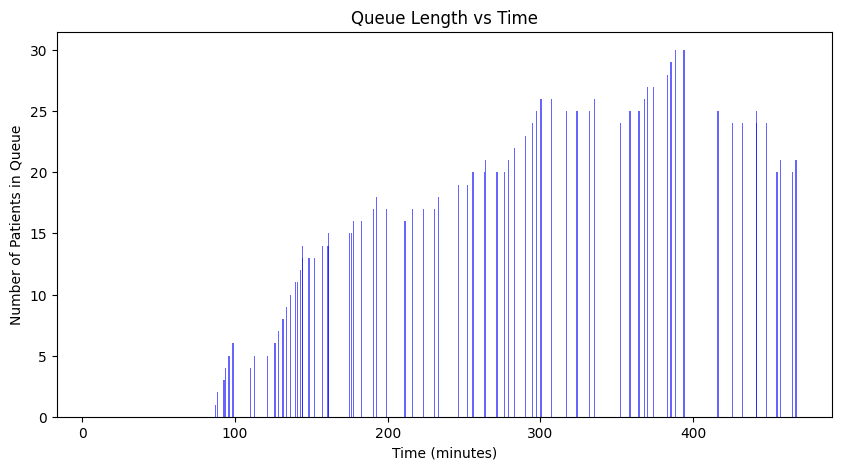

In [5]:
# Plot queue length over time
plt.figure(figsize=(10, 5))
plt.bar(time_stamps, queue_lengths, color='blue', alpha=0.6)
plt.xlabel("Time (minutes)")
plt.ylabel("Number of Patients in Queue")
plt.title("Queue Length vs Time")
plt.show()

## Waiting time vs arrival rate
In this code, a line graph is used to understand how different arrival rates affect the waiting time (in mintues) for the patients.

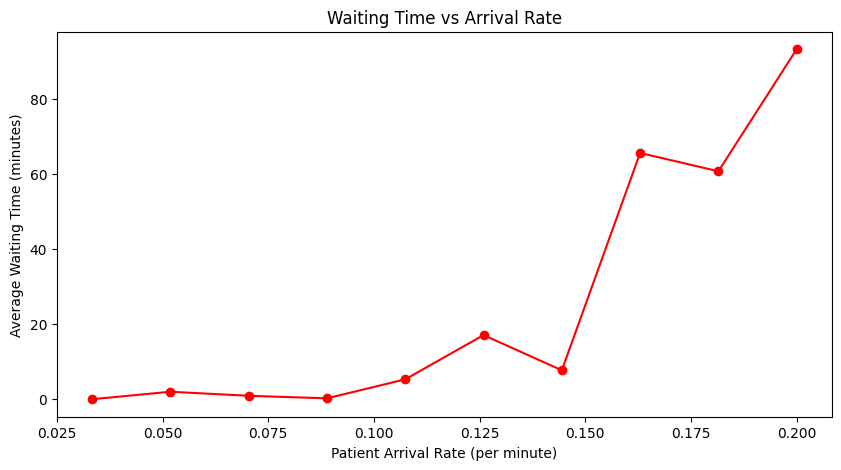

In [6]:
# Plot waiting time vs arrival rate
plt.figure(figsize=(10, 5))
plt.plot(lambda_rate, avg_wait_times, marker='o', linestyle='-', color='red')
plt.xlabel("Patient Arrival Rate (per minute)")
plt.ylabel("Average Waiting Time (minutes)")
plt.title("Waiting Time vs Arrival Rate")
plt.show()

## Oservation
The graph above illustrates the average waiting time in relation to different patient arrival rates at the clinic. It shows how the increasing number of patients affects the waiting time for service. At lower arrival rates, specifically 2 to 3 patients per hour, the waiting time is nearly 0 minutes. As the arrival rate increases to between 4 and 6 patients per hour, the waiting time rises to approximately 8 to 10 minutes. When the arrival rate exceeds 7 patients per hour, the waiting time escalates to around 20 minutes. A significant increase in the waiting time occurs once the arrival rate surpasses 9 patients per hour, with waiting times exceeding 1 hour (i.e., 60 minutes). This sharp increase indicates that the system has reached its maximum capacity, leading to longer queues. Additionally, as the arrival rates continue to climb, the waiting time can extend to more than 80 minutes, which is approximately 1.5 hours.

## Section 2: Possible solutions
The code below demonstrates possible soultions that can be applied to allocate the resources effectivly.

## General Idea
The proposed idea here is splitting the queue and dynamic allocation of the clinicians.

## Simulation
A new class is defined with the name `QueueSimulation2`, this will simulate the queue, arrival time of patient, service time and leave.

Here, the simulation will use `strategy` parameter to define the allocation of the sevice:
* `Baseline`: All customers will be alloted to the same server
* `Splliting`: Patients are splite in two classes, walk-in and scheduled customers
* `Dynamic`: Priorty based allocation 
 

In [7]:
class QueueSimulation2:
    def __init__(self, lambda_rate, mu_rate, duration, num_servers, strategy="baseline"):
        self.lambda_rate = lambda_rate 
        self.mu_rate = mu_rate  
        self.duration = duration  
        self.num_servers = num_servers  
        self.strategy = strategy  # baseline, splitting, or dynamic

    def generate_interarrival(self):
        return np.random.exponential(1. / self.lambda_rate)

    def generate_service(self):
        return np.random.exponential(1. / self.mu_rate)

    def Simulation(self, env, servers_walkin, servers_scheduled):
        self.num_customers = 0
        while True:
            yield env.timeout(self.generate_interarrival())  
            self.num_customers += 1
            is_walkin = np.random.rand() < 0.5  # Assume 50% walk-ins and 50% scheduled
            if self.strategy == "splitting":
                if is_walkin:
                    env.process(self.Customer(env, self.num_customers, servers_walkin))
                else:
                    env.process(self.Customer(env, self.num_customers, servers_scheduled))
            else:
                env.process(self.Customer(env, self.num_customers, servers_walkin))  

    def Customer(self, env, customer, servers):
        with servers.request() as request:
            t_arrival = env.now
            yield request  
            service_time = self.generate_service()
            yield env.timeout(service_time)  
            t_depart = env.now
            self.waits.append(t_depart - t_arrival)  
            self.service_t.append(service_time)  

    def run_simulation(self):
        self.waits = []
        self.service_t = []  
        self.num_customers = 0  

        env = simpy.Environment()
        
        if self.strategy == "splitting":
            servers_walkin = simpy.Resource(env, capacity=self.num_servers // 2)
            servers_scheduled = simpy.Resource(env, capacity=self.num_servers // 2)
        elif self.strategy == "dynamic":
            servers_walkin = simpy.PriorityResource(env, capacity=self.num_servers)  
            servers_scheduled = None  
        else:  
            servers_walkin = simpy.Resource(env, capacity=self.num_servers)  
            servers_scheduled = None  

        env.process(self.Simulation(env, servers_walkin, servers_scheduled))
        env.run(until=self.duration)

        average_service_time = np.mean(self.service_t) if self.service_t else 0
        average_wait_time = np.mean(self.waits) if self.waits else 0

        return average_service_time, average_wait_time  


The code below runs the simulation and store waiting time of the paitents for different arrival rates and different allocations strategies applied.

The strategies are:
- Baseline Model – All four clinicians serve patients on a first-come, first-served basis.

- Splitting Model – Two clinicians handle scheduled appointments, while two serve walk-ins.

- Dynamic Staffing Model – Clinician allocation shifts dynamically based on real-time demand.

In [16]:
# Simulate different arrival rates
arrival_rates = np.linspace(2, 12, 10)
service_time = 30 / 60  
mu = 1 / service_time  
duration = 480  
num_servers = 4  

waiting_baseline = []
waiting_splitting = []
waiting_dynamic = []

for lam in arrival_rates:
    sim_baseline = QueueSimulation2(lam, mu, duration, num_servers, "baseline")
    _, avg_wait_baseline = sim_baseline.run_simulation()
    waiting_baseline.append(avg_wait_baseline)

    sim_splitting = QueueSimulation2(lam, mu, duration, num_servers, "splitting")
    _, avg_wait_splitting = sim_splitting.run_simulation()
    waiting_splitting.append(avg_wait_splitting)

    sim_dynamic = QueueSimulation2(lam, mu, duration, num_servers, "dynamic")
    _, avg_wait_dynamic = sim_dynamic.run_simulation()
    waiting_dynamic.append(avg_wait_dynamic)

Below is the plot, comparing the basline, splitting strategy and dynamic allocation strategy of the model

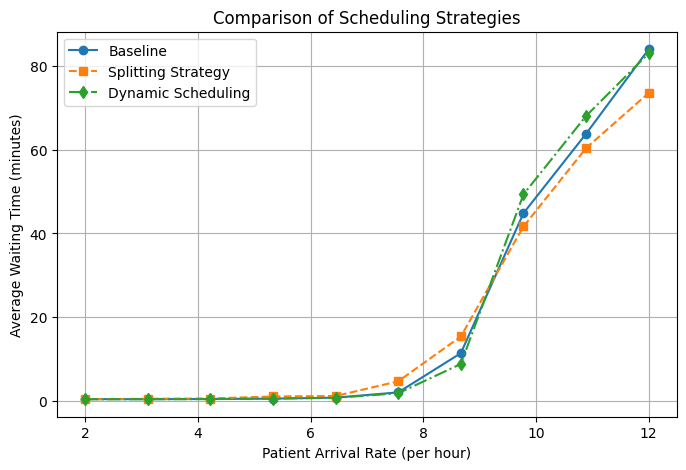

In [17]:
# Plot Comparison
plt.figure(figsize=(8, 5))
plt.plot(arrival_rates, waiting_baseline, marker='o', linestyle='-', label="Baseline")
plt.plot(arrival_rates, waiting_splitting, marker='s', linestyle='--', label="Splitting Strategy")
plt.plot(arrival_rates, waiting_dynamic, marker='d', linestyle='-.', label="Dynamic Scheduling")
plt.xlabel("Patient Arrival Rate (per hour)")
plt.ylabel("Average Waiting Time (minutes)")
plt.title("Comparison of Scheduling Strategies")
plt.legend()
plt.grid(True)
plt.show()

The graph illustrates performance of various queueing strategies based on average wait time over fluctuating patient arrivals.

   - `Baseline`: The blue line represents the baseline scenario, where the waiting time increases as patient arrival rates increase.

   - `Splitting`: The orange line represents the splitting strategy. This strategy splits the cliniciens assuming that half of the patients have scheduled appointments and half are walk-ins, we allocate two clinicians for walk-ins and two for appointments.This strategy reduceses the waiting times, but is only effective for appointments scheduled patients.

   - `Dynamic`: The green line represents the dynamic queueing strategy. It can bee seen that the dynamic allocation showes slightly lower waiting time compared to other strategies. Dyanamic allocation performs better during periods of high patient arrival rates.

   ## Conclusion
   By applying the strategies, the service of the clinic can be improved. The Splitting Strategy aims to divide patient flow more effectively, helping to slightly reduce wait times. In contrast, Dynamic Scheduling is highly flexible, adjusting appointments in real time based on demand.